In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/Volumes/SandiskSSD/Developer/AI_Document/Financial_Fraud_Detection_Thesis/data/AIML_dataset.csv')

In [3]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [3]:
df.shape

(6362620, 11)

In [18]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [6]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [7]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [10]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [17]:
# Percentage of fraud
round(df["isFraud"].value_counts()[1] / df.shape[0] * 100, 2)

np.float64(0.13)

In [30]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [38]:
correct_fraud_predicts = ((df["isFlaggedFraud"] == 1) & (df["isFraud"] == 1)).sum()
fraud_predicts = (df["isFlaggedFraud"] == 1).sum()

print(correct_fraud_predicts)
print(fraud_predicts)

16
16


In [39]:
tp = ((df["isFraud"] == 1) & (df["isFlaggedFraud"] == 1)).sum()
fp = ((df["isFraud"] == 0) & (df["isFlaggedFraud"] == 1)).sum()
fn = ((df["isFraud"] == 1) & (df["isFlaggedFraud"] == 0)).sum()
tn = ((df["isFraud"] == 0) & (df["isFlaggedFraud"] == 0)).sum()

In [40]:
print("TP:", tp)
print("FP:", fp)
print("FN:", fn)
print("TN:", tn)

TP: 16
FP: 0
FN: 8197
TN: 6354407


In [41]:
# The number rows which are flagged as fraud and indeed are fraud
# positive: fraud
# negative: no fraud
precision = tp / (tp + fp)
precision

np.float64(1.0)

In [43]:
recall = tp / (tp + fn)
recall
# This means, it only caught 0.19% of the number of frauds

np.float64(0.0019481310118105442)

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
isFraud = df.isFraud
isFlaggedFraud = df.isFlaggedFraud
cm = confusion_matrix(isFraud, isFlaggedFraud)
print(cm)

# Top-Left: True Negatives (TN)
# Top-Right: False Positives (FP)
# Bottom-Left: False Negatives (FN)
# Bottom-Right: True Positives (TP)

[[6354407       0]
 [   8197      16]]


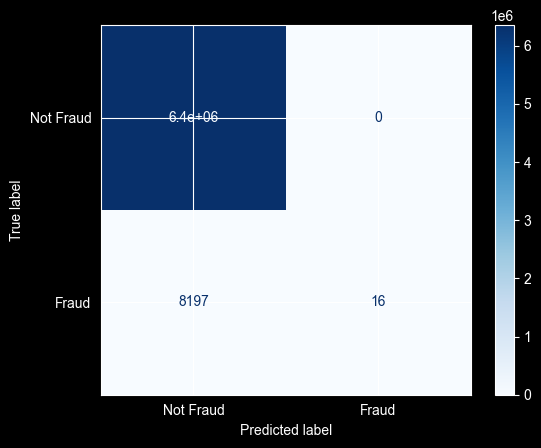

In [58]:
# Define display labels for clarity
display_labels = ['Not Fraud', 'Fraud']

# Create the display object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

# Plot the matrix
disp.plot(cmap=plt.cm.Blues) # Use a color map (e.g., 'Blues') for better visualization
plt.show()

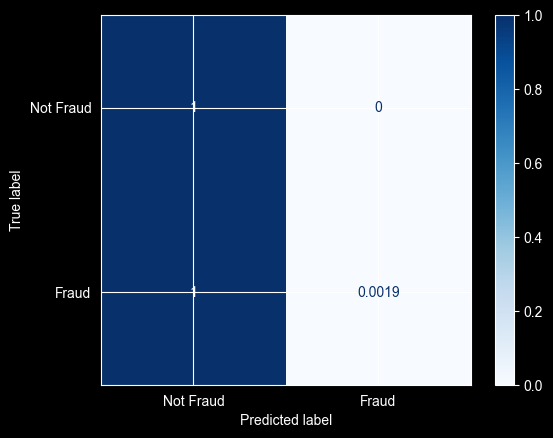

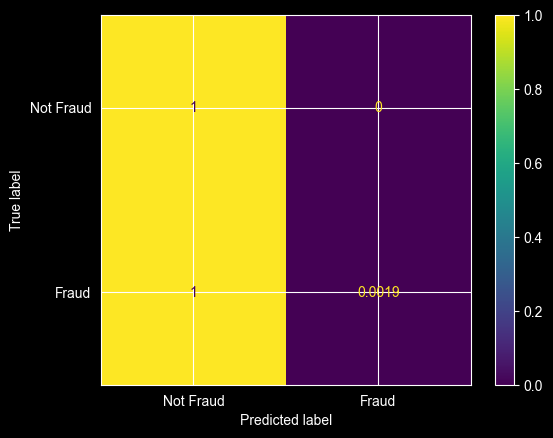

In [62]:
# Normalize over the true conditions (rows sum to 1 or 100%)
disp_norm = ConfusionMatrixDisplay.from_predictions(isFraud, isFlaggedFraud, normalize='true', cmap=plt.cm.Blues, display_labels=display_labels)
disp_norm.plot()

In [63]:
from sklearn.metrics import classification_report

report = classification_report(isFraud, isFlaggedFraud, target_names=display_labels)
print(report)


              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00   6354407
       Fraud       1.00      0.00      0.00      8213

    accuracy                           1.00   6362620
   macro avg       1.00      0.50      0.50   6362620
weighted avg       1.00      1.00      1.00   6362620



In [37]:
check = (df["isFraud"][2] == 1) & (df["isFlaggedFraud"][2] == 1)
check

np.False_

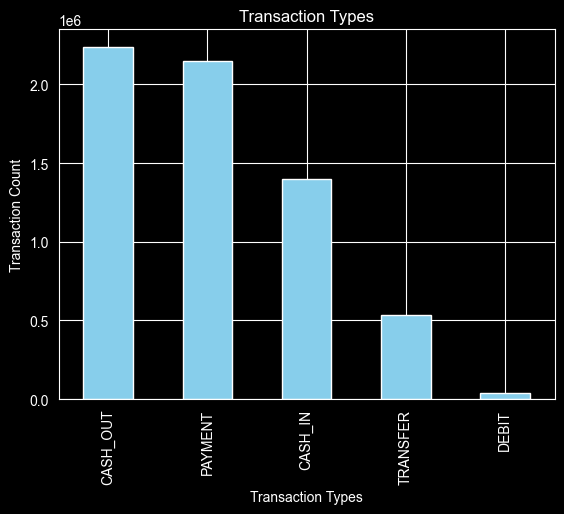

In [49]:
df["type"].value_counts().plot(kind="bar", color="skyblue", title= "Transaction Types")
plt.xlabel("Transaction Types")
plt.ylabel("Transaction Count")
plt.show()

In [93]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


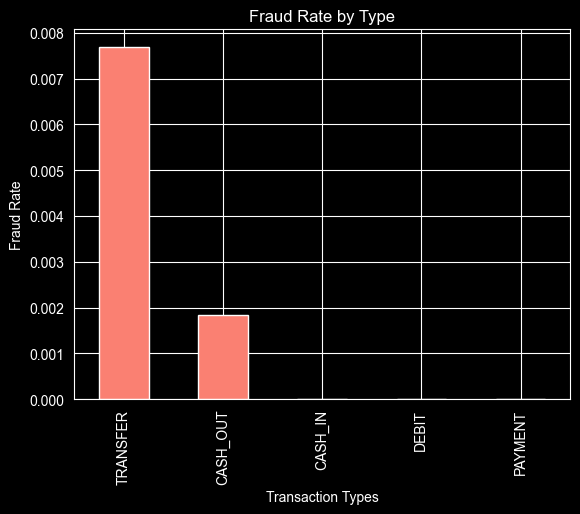

In [54]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
print(fraud_by_type)

fraud_by_type.plot(kind="bar", title="Fraud Rate by Type", color="salmon")
plt.xlabel("Transaction Types")
plt.ylabel("Fraud Rate")
plt.show()

In [66]:
df.amount.describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

<Axes: xlabel='count', ylabel='Count'>

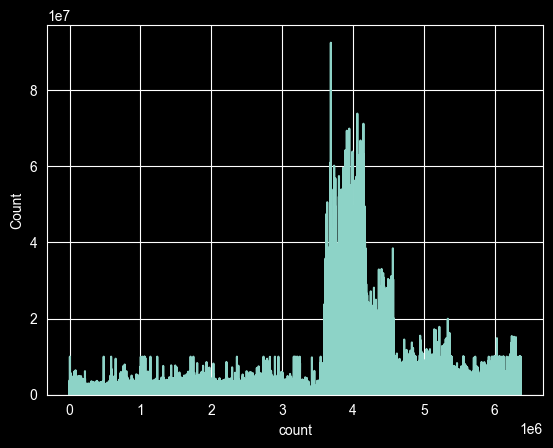

In [67]:
import seaborn as sns
sns.histplot(np.log1p(df["amount"].value_counts()))
df.amount.plot()

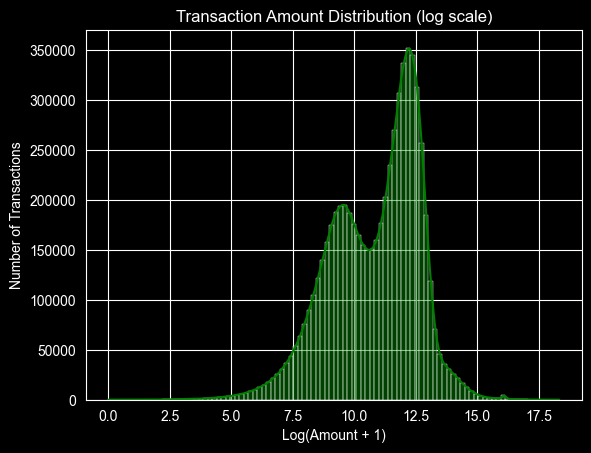

In [69]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde = True, color = "green")
plt.title("Transaction Amount Distribution (log scale)")
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Number of Transactions")
plt.show()
plt.show()

<Axes: xlabel='amount', ylabel='Count'>

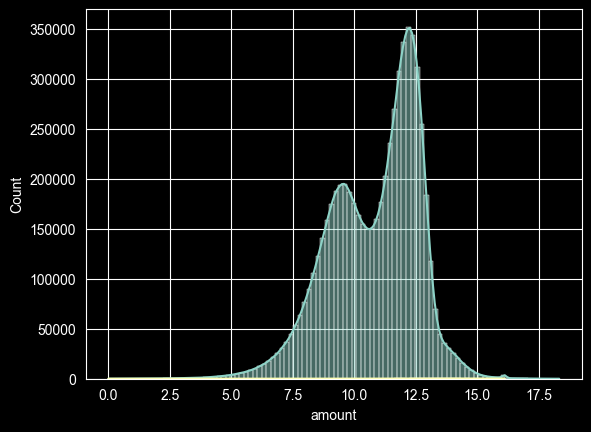

In [71]:
sns.histplot(np.log1p(df[df["isFraud"] == 0]["amount"]), bins=100, kde=True)
sns.histplot(np.log1p(df[df["isFraud"] == 1]["amount"]), bins=100, kde=True)

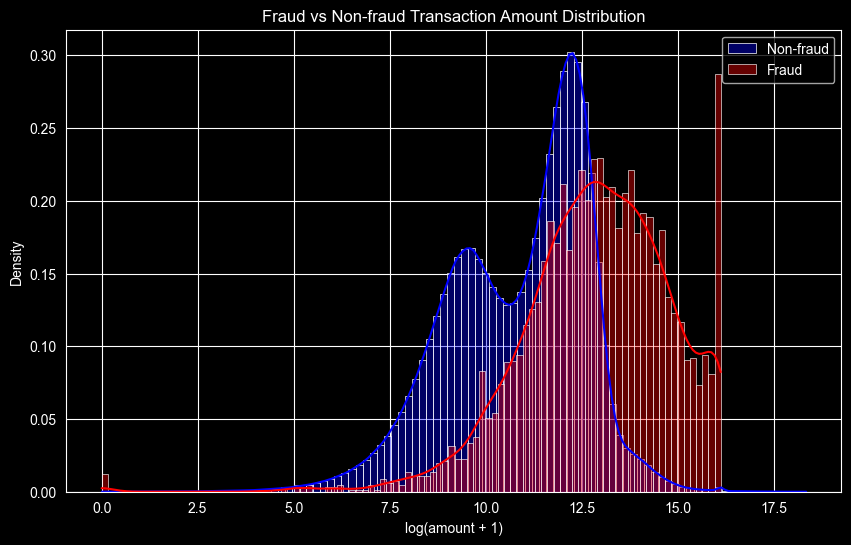

In [72]:
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(df[df["isFraud"] == 0]["amount"]), bins=100, stat="density", kde=True, color="blue", alpha=0.4, label="Non-fraud")
sns.histplot(np.log1p(df[df["isFraud"] == 1]["amount"]), bins=100, stat="density", kde=True, color="red", alpha=0.4, label="Fraud")
plt.legend()
plt.xlabel("log(amount + 1)")
plt.title("Fraud vs Non-fraud Transaction Amount Distribution")
plt.show()

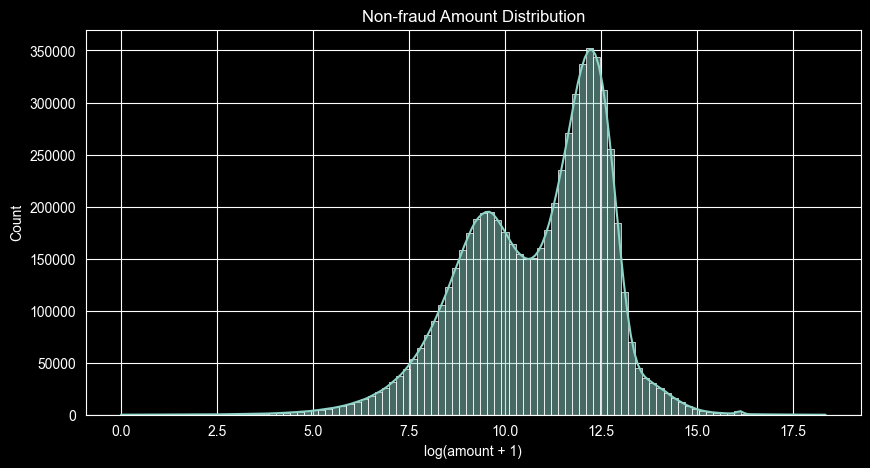

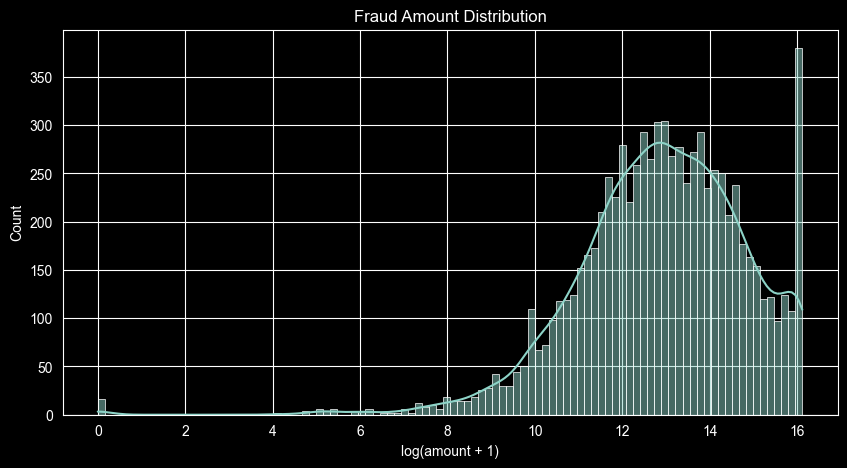

In [73]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df[df["isFraud"] == 0]["amount"]), bins=100, kde=True)
plt.title("Non-fraud Amount Distribution")
plt.xlabel("log(amount + 1)")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df[df["isFraud"] == 1]["amount"]), bins=100, kde=True)
plt.title("Fraud Amount Distribution")
plt.xlabel("log(amount + 1)")
plt.show()

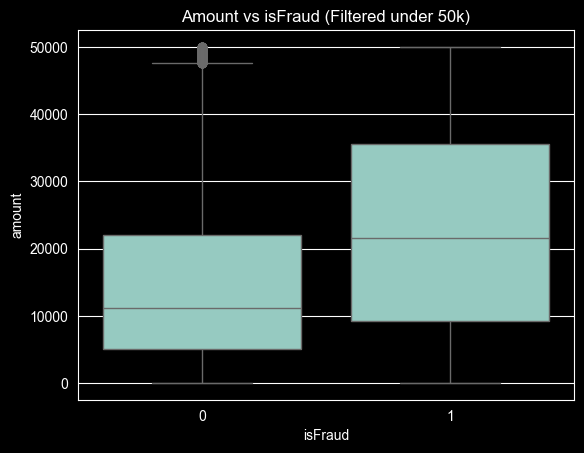

In [75]:
sns.boxplot(data = df[df["amount"] < 50000], x = "isFraud", y = "amount")
plt.title("Amount vs isFraud (Filtered under 50k)")
plt.show()

In [84]:
top_senders = df["nameOrig"].value_counts().head(10)
top_senders

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
C1976208114    3
C1784010646    3
C1530544995    3
C1902386530    3
C1677795071    3
Name: count, dtype: int64

In [85]:
top_receivers = df["nameDest"].value_counts().head(10)
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [89]:
fraud_users = df[df["isFraud"] == 1]["nameOrig"].value_counts().head(10)
fraud_users

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [90]:
fraud_users = df[df["isFraud"] == 1]["nameDest"].value_counts().head(10)
fraud_users

nameDest
C410033330     2
C803116137     2
C904300960     2
C1013511446    2
C2020337583    2
C200064275     2
C185805228     2
C52390890      2
C935310781     2
C1827219533    2
Name: count, dtype: int64

In [92]:
fraud_types = df[df["type"].isin(["CASH_OUT", "TRANSFER"])]
fraud_types

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0
15,1,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0,0
19,1,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0,0
24,1,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0


In [95]:
fraud_types.type.value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

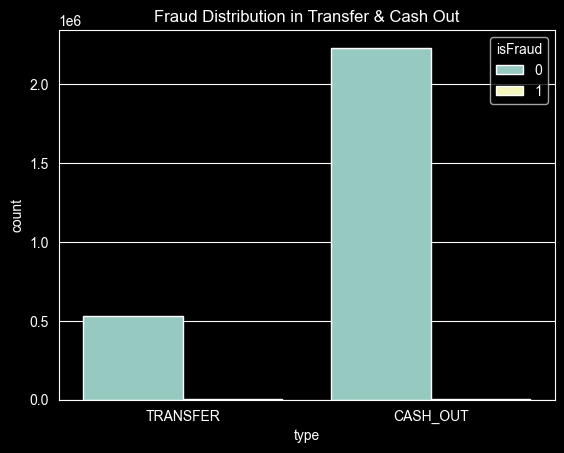

In [98]:
sns.countplot(data=fraud_types, x="type", hue="isFraud")
plt.title("Fraud Distribution in Transfer & Cash Out")
plt.show()


In [108]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [112]:
corr = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud", "isFlaggedFraud"]].corr()
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688,0.012295
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154,0.003835
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148,0.003776
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885,-0.000513
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535,-0.000529
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000,0.044109
isFlaggedFraud,0.012295,0.003835,0.003776,-0.000513,-0.000529,0.044109,1.000000


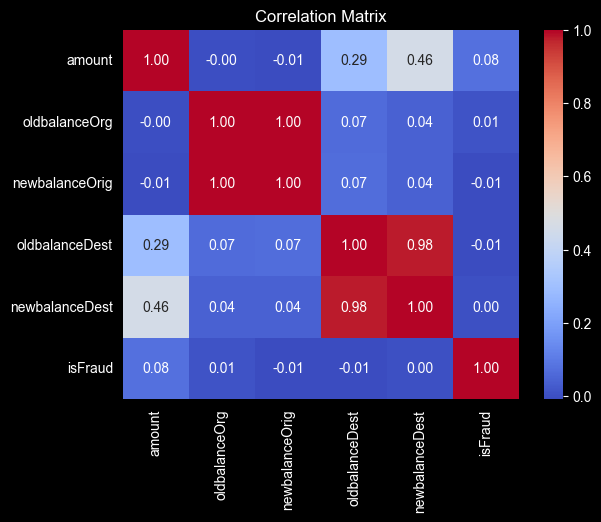

In [111]:
corr = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [115]:
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0) &
    (df["type"].isin(["CASH_OUT", "TRANSFER"]))
]

len(zero_after_transfer)

1188074

In [116]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder